In [13]:
import torch
import torch.nn as nn

class NoSkip(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Encoder ---
        self.enc_conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.enc_relu1 = nn.ReLU()

        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.enc_relu2 = nn.ReLU()

        # --- Decoder ---
        self.dec_deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.dec_relu1  = nn.ReLU()

        self.dec_deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        # Encoder
        x = self.enc_conv1(x)
        x = self.enc_relu1(x)

        x = self.enc_conv2(x)
        x = self.enc_relu2(x)

        # Decoder
        x = self.dec_deconv1(x)
        x = self.dec_relu1(x)

        x = self.dec_deconv2(x)
        x = torch.sigmoid(x)
        return x


In [14]:
import torch
import torch.nn as nn

class WithSkip(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Encoder ---
        self.e1_conv = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.e1_relu = nn.ReLU()

        self.e2_conv = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.e2_relu = nn.ReLU()

        # --- Decoder ---
        # 첫 업샘플: 64 → 32
        self.d1_deconv = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.d1_relu   = nn.ReLU()

        # 두 번째 업샘플: (32 + 32) → 1  (skip 때문에 64채널 입력)
        self.d2_deconv = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        # Encoder
        e1 = self.e1_conv(x)
        e1 = self.e1_relu(e1)

        e2 = self.e2_conv(e1)
        e2 = self.e2_relu(e2)

        # Decoder — 첫 업샘플
        d1 = self.d1_deconv(e2)
        d1 = self.d1_relu(d1)

        # ⭐ Skip 연결: d1 + e1 → concat
        cat = torch.cat([d1, e1], dim=1)

        # 두 번째 업샘플
        out = self.d2_deconv(cat)
        out = torch.sigmoid(out)
        return out


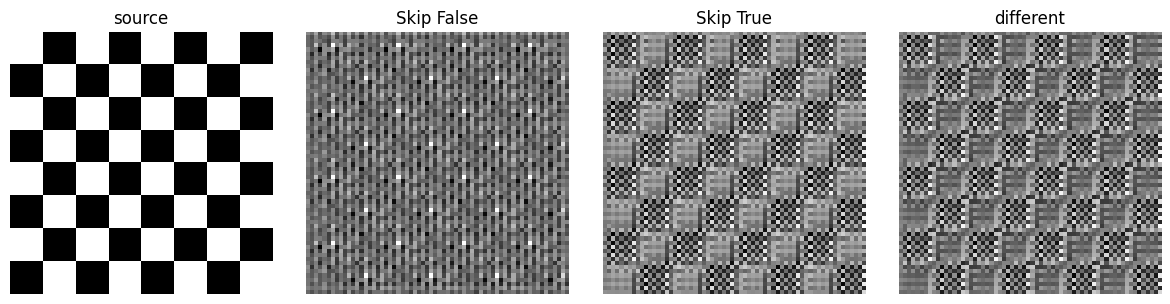

MSE (Skip 없음): 0.2535
MSE (Skip 있음): 0.2884


In [15]:
# 테스트 이미지 생성 (체커보드 패턴 - 경계가 뚜렷함)
def make_test_image(size=64):
    img = torch.zeros(1, 1, size, size)
    for i in range(0, size, 8):
        for j in range(0, size, 8):
            if (i//8 + j//8) % 2 == 0:
                img[0, 0, i:i+8, j:j+8] = 1.0
    return img

# 실행 및 시각화
img = make_test_image()
no_skip, with_skip = NoSkip(), WithSkip()

with torch.no_grad():
    out_no_skip = no_skip(img)
    out_with_skip = with_skip(img)

# 시각화
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
titles = ['source', 'Skip False', 'Skip True', 'different']
images = [img, out_no_skip, out_with_skip, torch.abs(img - out_no_skip) - torch.abs(img - out_with_skip)]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(im.squeeze(), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig('skip_comparison.png', dpi=150)
plt.show()

# 수치로 비교
print(f"MSE (Skip 없음): {((img - out_no_skip)**2).mean():.4f}")
print(f"MSE (Skip 있음): {((img - out_with_skip)**2).mean():.4f}")